# Exercício:

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que não há uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

## 01 – Descreva o racional da sua resposta:

R.: R.: O programa lê o arquivo CSV e organiza os dados em um DataFrame, em seguida realiza a transposição para que cada gene passe a ser representado por uma linha. Após renomear as colunas, o código calcula o número de caracteres do nome de cada gene e adiciona essa informação de frequência como uma nova coluna. Com base nesses valores é construída uma tabela de frequência que contabiliza quantos genes possuem cada tamanho de nome. Essa frequência é então integrada à DataFrame principal por meio de uma junção, associando a cada gene sua respectiva frequência. Por fim, o código printa de um gráfico de barras com a distribuição dessas frequências. 

## 02 – Desenhe o fluxograma da resposta:

<img src="./img/fluxograma1atv13.png" width = "400"  /> 

## 03 – Escreva o programa em Python:

Tabela de frequência:
   tamanho_nome  frequencia
0             5           1
1            11           1
2            17           1
3            21           1
4            30           1

DataFrame final:
  tamanho nome primeiras letras quantidade de a presenca hu  tamanho_nome  \
0           21               He               1       False            21   
1           11               hi               0       False            11   
2           30               cy               1       False            30   
3            5               ac               1       False             5   
4           17               18               2       False            17   

   frequencia  
0           1  
1           1  
2           1  
3           1  
4           1  


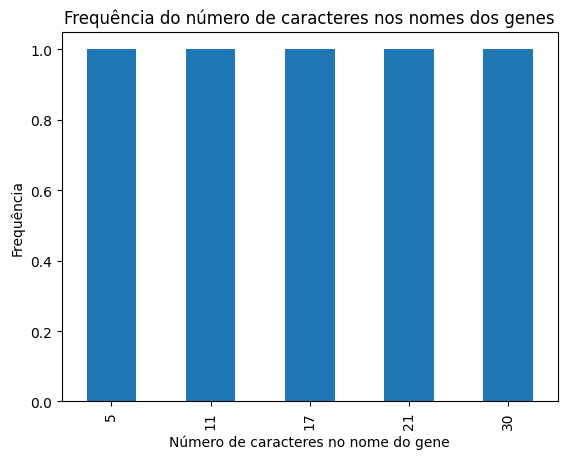

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("df_genes.csv")

df_t = df.T

df_t.columns = ['tamanho nome', 'primeiras letras', 'quantidade de a', 'presenca hu']

#coluna com o número de caracteres do nome dos genes
df_t['tamanho_nome'] = df_t.index.str.len()

# tabela de frequência
freq = df_t['tamanho_nome'].value_counts().sort_index()

# DataFrame
df_freq = freq.reset_index()
df_freq.columns = ['tamanho_nome', 'frequencia']

print("Tabela de frequência:")
print(df_freq)


df_final = df_t.merge(df_freq, on='tamanho_nome')

print("\nDataFrame final:")
print(df_final)

# gráfico 
freq.plot(kind='bar')
plt.xlabel("Número de caracteres no nome do gene")
plt.ylabel("Frequência")
plt.title("Frequência do número de caracteres nos nomes dos genes")
plt.show()

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que há uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

## 04 – Descreva o racional da sua resposta:

Primeiramente o código extrai os nomes dos genes dos cabeçalhos das colunas do CSV, o comprimento de cada nome é calculado e armazenado em um DataFrame auxiliar. Em seguida, usei value_counts() seguido de sort_index() para gerar a tabela de frequência dos tamanhos, e  essa frequência é inserida no DataFrame original com map(), associando cada tamanho à sua contagem total. No final, é plotado um gráfico de barras diretamente da tabela de frequência (freq.plot(kind='bar')), configurando os rótulos dos eixos e o título para visualizar a distribuição do número de caracteres nos nomes dos genes.


## 05 – Desenhe o fluxograma da resposta:

<img src="./img/fluxograma2atv13.png" width = "400"  /> 


## 06 – Escreva o programa em Python:

                             gene  tamanho_nome  frequencia
0           Heat shock protein 70            21           1
1                     histone H2B            11           1
2  cytochrome c oxidase subunit 1            30           1
3                           actin             5           1
4               18S ribosomal RNA            17           1


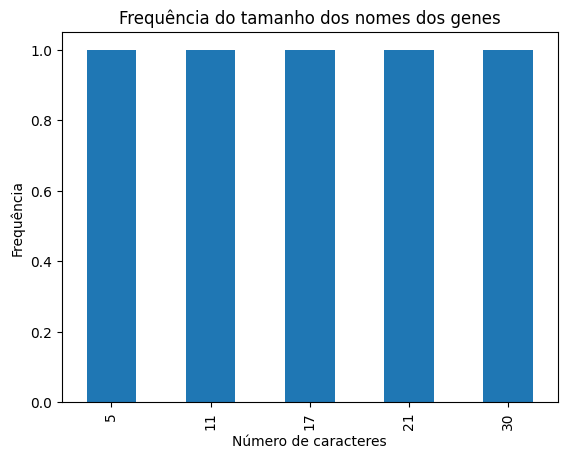

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("df_genes.csv")


genes = df.columns

# DataFrame auxiliar
df_genes = pd.DataFrame({
    'gene': genes,
    'tamanho_nome': [len(g) for g in genes]
})

# tabela de frequência
freq = df_genes['tamanho_nome'].value_counts().sort_index()

# inserir frequência mantendo ordem
df_genes['frequencia'] = df_genes['tamanho_nome'].map(freq)

print(df_genes)

freq.plot(kind='bar')
plt.xlabel("Número de caracteres")
plt.ylabel("Frequência")
plt.title("Frequência do tamanho dos nomes dos genes")
plt.show()

## 07 – Reorganize a DataFrame, removendo as colunas contendo os dois primeiros caracteres, o número de caracter 'a', e a presença de 'hu', dos genes. Renomeie as colunas de acordo com as informações. Adicione uma coluna com a informação de 'Amostra 1'.

In [ ]:
import pandas as pd

df = pd.read_csv("df_genes.csv")


df_filtrado = df.loc[[0]]

df_filtrado.index = ['tamanho_nome']

# adicionar coluna "Amostra 1"
df_filtrado['Amostra 1'] = 9

df_filtrado


,Heat shock protein 70,histone H2B,cytochrome c oxidase subunit 1,actin,18S ribosomal RNA,Amostra 1
tamanho_nome,21,11,30,5,17,9


## 08 – Usando a função randint(), da classe random do módulo numpy (np.random.randint(1,10,5)), instancie objeto da classe numpy array. Calcule as frequências desta nova amostra, considerando que à uma ordem entre os genes. Insira na DataFrame este objeto como "Amostra 2".

In [ ]:
import numpy as np

num_colunas = df_filtrado.shape[1]


amostra_2_array = np.random.randint(1, 10, size=num_colunas)

df_filtrado.loc['Amostra 2'] = amostra_2_array

df_filtrado

,Heat shock protein 70,histone H2B,cytochrome c oxidase subunit 1,actin,18S ribosomal RNA,Amostra 1
tamanho_nome,21,11,30,5,17,9
Amostra 2,4,3,6,9,4,5


## 09 – Repita o exercício 8, inserindo na DataFrame as replicas "Amostra 3“, "Amostra 4“, "Amostra 5“ e "Amostra 6".

In [22]:
import numpy as np

novas_amostras = ["Amostra 3", "Amostra 4", "Amostra 5", "Amostra 6"]

# quantidade de colunas atual para evitar o erro de "mismatched columns"
num_colunas = df_filtrado.shape[1]


for nome_amostra in novas_amostras:
    # Gera 1 array aleatório para cada iteração
    valores_aleatorios = np.random.randint(1, 10, size=num_colunas)
    
    
    df_filtrado.loc[nome_amostra] = valores_aleatorios

df_filtrado

,Heat shock protein 70,histone H2B,cytochrome c oxidase subunit 1,actin,18S ribosomal RNA,Amostra 1
tamanho_nome,21,11,30,5,17,9
Amostra 2,4,3,6,9,4,5
Amostra 3,6,4,5,9,7,5
Amostra 4,8,2,2,5,8,2
Amostra 5,7,3,9,7,1,7
Amostra 6,2,4,6,2,5,1


## 10 – Obtenha dos seus dados o gráfico abaixo, adicionando 3 replicas.

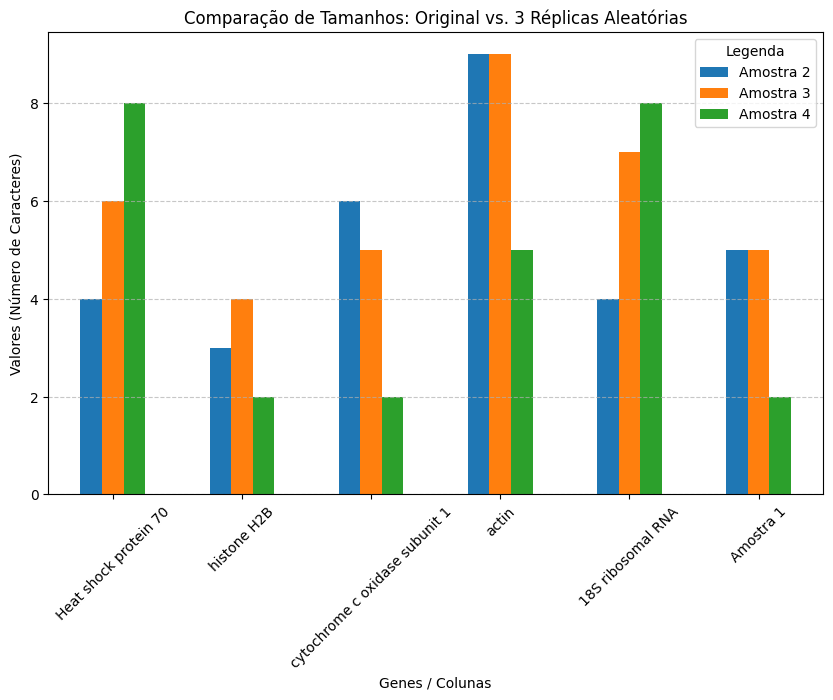

In [24]:
import matplotlib.pyplot as plt

# 'tamanho_nome'  + as Amostras 2, 3 e 4 (3 réplicas)
df_plot = df_filtrado.loc[['tamanho_nome', 'Amostra 2', 'Amostra 3', 'Amostra 4']]

# Transpor para que os Genes fiquem no eixo X e as Amostras na legenda
df_plot.T.plot(kind='bar', figsize=(10, 6))

plt.title("Comparação de Tamanhos: Original vs. 3 Réplicas Aleatórias")
plt.xlabel("Genes / Colunas")
plt.ylabel("Valores (Número de Caracteres)")
plt.legend(title="Legenda")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()